# 10-Year Rental Property Return Analysis

Compare the 10-year investment performance of two long-term rental properties in Celina, Texas.

- Property A purchase price: $350,000
- Property B purchase price: $550,000
- Down payment: $250,000 for each property
- Mortgage rate: 6.8%
- Holding period: 10 years
- Assume properties are sold at the end of Year 10

The analysis combines rental cash flow, property appreciation, mortgage amortization, selling costs, and net sale proceeds to determine which property produces the stronger total return.

## 1. Imports

In [1]:
import copy

import numpy as np
import numpy_financial as npf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from scipy.optimize import brentq

pd.options.display.float_format = "{:,.2f}".format

## 2. Assumptions

The initial assumptions reproduce the verified spreadsheet model. All rates are entered as decimals.

In [2]:
common_assumptions = {
    "location": "Celina, TX",
    "down_payment": 250_000,
    "mortgage_rate": 0.068,
    "mortgage_term_years": 30,
    "holding_period_years": 10,
    "annual_rent_growth": 0.00,
    "vacancy_rate": 0.05,
    "property_tax_rate": 0.02016,
    "monthly_hoa": 0,
    "management_fee_rate": 0.00,
    "annual_appreciation": 0.03,
    "buying_cost_rate": 0.02,
    "selling_cost_rate": 0.07,
    "initial_renovation_cost": 0,
    "annual_insurance_growth": 0.00,
}

In [3]:
property_a = {
    **common_assumptions,
    "property_name": "Property A",
    "purchase_price": 350_000,
    "monthly_rent": 2_500,
    "annual_insurance": 3_500,
    "annual_maintenance": 3_500,
}

property_b = {
    **common_assumptions,
    "property_name": "Property B",
    "purchase_price": 520_000,
    "monthly_rent": 3_500,
    "annual_insurance": 5_500,
    "annual_maintenance": 5_500,
}

In [4]:
assumptions_table = pd.DataFrame({
    "Property A": property_a,
    "Property B": property_b,
})

assumptions_table

,Property A,Property B
location,"Celina, TX","Celina, TX"
down_payment,250000,250000
mortgage_rate,0.07,0.07
mortgage_term_years,30,30
holding_period_years,10,10
annual_rent_growth,0.00,0.00
vacancy_rate,0.05,0.05
property_tax_rate,0.02,0.02
monthly_hoa,0,0
management_fee_rate,0.00,0.00


## 3. Mortgage Calculations

The mortgage payment remains fixed, while the remaining principal balance decreases over the holding period.

In [5]:
def calculate_mortgage_balance(
    mortgage_amount,
    annual_mortgage_rate,
    mortgage_term_years,
    payments_made,
):
    monthly_rate = annual_mortgage_rate / 12

    monthly_payment = -npf.pmt(
        monthly_rate,
        mortgage_term_years * 12,
        mortgage_amount,
    )

    remaining_balance = -npf.fv(
        monthly_rate,
        payments_made,
        -monthly_payment,
        mortgage_amount,
    )

    return max(float(remaining_balance), 0.0)

## 4. 10-Year Investment Projection

The following function calculates annual income, expenses, property value, mortgage balance, cash flow, and sale proceeds.

In [6]:
def project_property(assumptions):
    property_name = assumptions["property_name"]
    purchase_price = assumptions["purchase_price"]
    down_payment = assumptions["down_payment"]

    mortgage_amount = purchase_price - down_payment
    monthly_rate = assumptions["mortgage_rate"] / 12
    total_mortgage_payments = assumptions["mortgage_term_years"] * 12

    monthly_mortgage_payment = -npf.pmt(
        monthly_rate,
        total_mortgage_payments,
        mortgage_amount,
    )

    annual_mortgage_payment = monthly_mortgage_payment * 12

    initial_cash_investment = (
        down_payment
        + purchase_price * assumptions["buying_cost_rate"]
        + assumptions["initial_renovation_cost"]
    )

    annual_records = []
    beginning_property_value = purchase_price

    for year in range(1, assumptions["holding_period_years"] + 1):
        monthly_rent = (
            assumptions["monthly_rent"]
            * (1 + assumptions["annual_rent_growth"]) ** (year - 1)
        )

        scheduled_rent = monthly_rent * 12
        vacancy_loss = scheduled_rent * assumptions["vacancy_rate"]
        collected_rent = scheduled_rent - vacancy_loss

        property_tax = (
            beginning_property_value
            * assumptions["property_tax_rate"]
        )

        insurance = (
            assumptions["annual_insurance"]
            * (1 + assumptions["annual_insurance_growth"]) ** (year - 1)
        )

        maintenance = assumptions["annual_maintenance"]
        hoa = assumptions["monthly_hoa"] * 12
        management_fee = (
            collected_rent
            * assumptions["management_fee_rate"]
        )

        total_operating_expenses = (
            property_tax
            + insurance
            + maintenance
            + hoa
            + management_fee
        )

        noi = collected_rent - total_operating_expenses
        annual_cash_flow = noi - annual_mortgage_payment

        ending_property_value = (
            beginning_property_value
            * (1 + assumptions["annual_appreciation"])
        )

        payments_made = year * 12

        ending_mortgage_balance = calculate_mortgage_balance(
            mortgage_amount=mortgage_amount,
            annual_mortgage_rate=assumptions["mortgage_rate"],
            mortgage_term_years=assumptions["mortgage_term_years"],
            payments_made=payments_made,
        )

        ending_equity = (
            ending_property_value
            - ending_mortgage_balance
        )

        annual_records.append({
            "Property": property_name,
            "Year": year,
            "Beginning Property Value": beginning_property_value,
            "Monthly Rent": monthly_rent,
            "Scheduled Rent": scheduled_rent,
            "Vacancy Loss": vacancy_loss,
            "Collected Rent": collected_rent,
            "Property Tax": property_tax,
            "Insurance": insurance,
            "Maintenance": maintenance,
            "HOA": hoa,
            "Management Fee": management_fee,
            "Total Operating Expenses": total_operating_expenses,
            "NOI": noi,
            "Mortgage Payments": annual_mortgage_payment,
            "Annual Cash Flow": annual_cash_flow,
            "Ending Property Value": ending_property_value,
            "Ending Mortgage Balance": ending_mortgage_balance,
            "Ending Equity": ending_equity,
        })

        beginning_property_value = ending_property_value

    annual_projection = pd.DataFrame(annual_records)

    projected_sale_price = annual_projection.iloc[-1][
        "Ending Property Value"
    ]

    remaining_mortgage = annual_projection.iloc[-1][
        "Ending Mortgage Balance"
    ]

    selling_costs = (
        projected_sale_price
        * assumptions["selling_cost_rate"]
    )

    net_sale_proceeds = (
        projected_sale_price
        - selling_costs
        - remaining_mortgage
    )

    cumulative_cash_flow = annual_projection[
        "Annual Cash Flow"
    ].sum()

    total_profit = (
        cumulative_cash_flow
        + net_sale_proceeds
        - initial_cash_investment
    )

    total_return = total_profit / initial_cash_investment

    simplified_annualized_return = (
        (1 + total_return)
        ** (1 / assumptions["holding_period_years"])
        - 1
    )

    summary = {
        "Property": property_name,
        "Purchase Price": purchase_price,
        "Down Payment": down_payment,
        "Mortgage Amount": mortgage_amount,
        "Monthly Mortgage Payment": monthly_mortgage_payment,
        "Initial Cash Investment": initial_cash_investment,
        "Year 1 Cash Flow": annual_projection.iloc[0][
            "Annual Cash Flow"
        ],
        "Cumulative Cash Flow": cumulative_cash_flow,
        "Projected Sale Price": projected_sale_price,
        "Selling Costs": selling_costs,
        "Remaining Mortgage": remaining_mortgage,
        "Net Sale Proceeds": net_sale_proceeds,
        "Total Profit": total_profit,
        "Total Return": total_return,
        "Simplified Annualized Return": simplified_annualized_return,
    }

    return annual_projection, summary

In [7]:
property_a_projection, property_a_summary = project_property(property_a)
property_b_projection, property_b_summary = project_property(property_b)

In [8]:
# display Property A
property_a_projection

,Property,Year,Beginning Property Value,Monthly Rent,Scheduled Rent,Vacancy Loss,Collected Rent,Property Tax,Insurance,Maintenance,HOA,Management Fee,Total Operating Expenses,NOI,Mortgage Payments,Annual Cash Flow,Ending Property Value,Ending Mortgage Balance,Ending Equity
0,Property A,1,"350,000.00","2,500.00","30,000.00","1,500.00","28,500.00","7,056.00","3,500.00",3500,0,0.00,"14,056.00","14,444.00","7,823.10","6,620.90","360,500.00","98,944.40","261,555.60"
1,Property A,2,"360,500.00","2,500.00","30,000.00","1,500.00","28,500.00","7,267.68","3,500.00",3500,0,0.00,"14,267.68","14,232.32","7,823.10","6,409.22","371,315.00","97,814.74","273,500.26"
2,Property A,3,"371,315.00","2,500.00","30,000.00","1,500.00","28,500.00","7,485.71","3,500.00",3500,0,0.00,"14,485.71","14,014.29","7,823.10","6,191.19","382,454.45","96,605.82","285,848.63"
3,Property A,4,"382,454.45","2,500.00","30,000.00","1,500.00","28,500.00","7,710.28","3,500.00",3500,0,0.00,"14,710.28","13,789.72","7,823.10","5,966.62","393,928.08","95,312.09","298,615.99"
4,Property A,5,"393,928.08","2,500.00","30,000.00","1,500.00","28,500.00","7,941.59","3,500.00",3500,0,0.00,"14,941.59","13,558.41","7,823.10","5,735.31","405,745.93","93,927.59","311,818.34"
5,Property A,6,"405,745.93","2,500.00","30,000.00","1,500.00","28,500.00","8,179.84","3,500.00",3500,0,0.00,"15,179.84","13,320.16","7,823.10","5,497.06","417,918.30","92,445.95","325,472.35"
6,Property A,7,"417,918.30","2,500.00","30,000.00","1,500.00","28,500.00","8,425.23","3,500.00",3500,0,0.00,"15,425.23","13,074.77","7,823.10","5,251.66","430,455.85","90,860.36","339,595.49"
7,Property A,8,"430,455.85","2,500.00","30,000.00","1,500.00","28,500.00","8,677.99","3,500.00",3500,0,0.00,"15,677.99","12,822.01","7,823.10","4,998.91","443,369.53","89,163.52","354,206.00"
8,Property A,9,"443,369.53","2,500.00","30,000.00","1,500.00","28,500.00","8,938.33","3,500.00",3500,0,0.00,"15,938.33","12,561.67","7,823.10","4,738.57","456,670.61","87,347.64","369,322.97"
9,Property A,10,"456,670.61","2,500.00","30,000.00","1,500.00","28,500.00","9,206.48","3,500.00",3500,0,0.00,"16,206.48","12,293.52","7,823.10","4,470.42","470,370.73","85,404.35","384,966.38"


In [9]:
# display Property B
property_b_projection

,Property,Year,Beginning Property Value,Monthly Rent,Scheduled Rent,Vacancy Loss,Collected Rent,Property Tax,Insurance,Maintenance,HOA,Management Fee,Total Operating Expenses,NOI,Mortgage Payments,Annual Cash Flow,Ending Property Value,Ending Mortgage Balance,Ending Equity
0,Property B,1,"520,000.00","3,500.00","42,000.00","2,100.00","39,900.00","10,483.20","5,500.00",5500,0,0.00,"21,483.20","18,416.80","21,122.38","-2,705.58","535,600.00","267,149.88","268,450.12"
1,Property B,2,"535,600.00","3,500.00","42,000.00","2,100.00","39,900.00","10,797.70","5,500.00",5500,0,0.00,"21,797.70","18,102.30","21,122.38","-3,020.07","551,668.00","264,099.80","287,568.20"
2,Property B,3,"551,668.00","3,500.00","42,000.00","2,100.00","39,900.00","11,121.63","5,500.00",5500,0,0.00,"22,121.63","17,778.37","21,122.38","-3,344.00","568,218.04","260,835.73","307,382.31"
3,Property B,4,"568,218.04","3,500.00","42,000.00","2,100.00","39,900.00","11,455.28","5,500.00",5500,0,0.00,"22,455.28","17,444.72","21,122.38","-3,677.65","585,264.58","257,342.65","327,921.94"
4,Property B,5,"585,264.58","3,500.00","42,000.00","2,100.00","39,900.00","11,798.93","5,500.00",5500,0,0.00,"22,798.93","17,101.07","21,122.38","-4,021.31","602,822.52","253,604.49","349,218.03"
5,Property B,6,"602,822.52","3,500.00","42,000.00","2,100.00","39,900.00","12,152.90","5,500.00",5500,0,0.00,"23,152.90","16,747.10","21,122.38","-4,375.28","620,907.19","249,604.07","371,303.13"
6,Property B,7,"620,907.19","3,500.00","42,000.00","2,100.00","39,900.00","12,517.49","5,500.00",5500,0,0.00,"23,517.49","16,382.51","21,122.38","-4,739.87","639,534.41","245,322.97","394,211.44"
7,Property B,8,"639,534.41","3,500.00","42,000.00","2,100.00","39,900.00","12,893.01","5,500.00",5500,0,0.00,"23,893.01","16,006.99","21,122.38","-5,115.39","658,720.44","240,741.52","417,978.93"
8,Property B,9,"658,720.44","3,500.00","42,000.00","2,100.00","39,900.00","13,279.80","5,500.00",5500,0,0.00,"24,279.80","15,620.20","21,122.38","-5,502.18","678,482.06","235,838.63","442,643.43"
9,Property B,10,"678,482.06","3,500.00","42,000.00","2,100.00","39,900.00","13,678.20","5,500.00",5500,0,0.00,"24,678.20","15,221.80","21,122.38","-5,900.57","698,836.52","230,591.75","468,244.76"


### 4.1 Comparison Table

In [10]:
comparison = pd.DataFrame([
    property_a_summary,
    property_b_summary,
]).set_index("Property").T

comparison["B - A"] = (
    comparison["Property B"]
    - comparison["Property A"]
)

comparison

Property,Property A,Property B,B - A
Purchase Price,"350,000.00","520,000.00","170,000.00"
Down Payment,"250,000.00","250,000.00",0.00
Mortgage Amount,"100,000.00","270,000.00","170,000.00"
Monthly Mortgage Payment,651.93,"1,760.20","1,108.27"
Initial Cash Investment,"257,000.00","260,400.00","3,400.00"
Year 1 Cash Flow,"6,620.90","-2,705.58","-9,326.47"
Cumulative Cash Flow,"55,879.84","-42,401.90","-98,281.75"
Projected Sale Price,"470,370.73","698,836.52","228,465.78"
Selling Costs,"32,925.95","48,918.56","15,992.60"
Remaining Mortgage,"85,404.35","230,591.75","145,187.40"


## 5. Validation against original spreadsheet

The Python model should reproduce the spreadsheet results before any scenarios or visualizations are added.

In [11]:
validation_values = pd.DataFrame({
    "Spreadsheet Property A": {
        "Monthly Mortgage Payment": 651.93,
        "Year 1 Cash Flow": 6_620.90,
        "Cumulative Cash Flow": 55_879.84,
        "Projected Sale Price": 470_370.73,
        "Remaining Mortgage": 85_404.35,
        "Total Profit": 150_920.27,
    },
    "Python Property A": {
        "Monthly Mortgage Payment": property_a_summary[
            "Monthly Mortgage Payment"
        ],
        "Year 1 Cash Flow": property_a_summary[
            "Year 1 Cash Flow"
        ],
        "Cumulative Cash Flow": property_a_summary[
            "Cumulative Cash Flow"
        ],
        "Projected Sale Price": property_a_summary[
            "Projected Sale Price"
        ],
        "Remaining Mortgage": property_a_summary[
            "Remaining Mortgage"
        ],
        "Total Profit": property_a_summary[
            "Total Profit"
        ],
    },
    "Updated Property B Benchmark": {
        "Monthly Mortgage Payment": 1_760.20,
        "Year 1 Cash Flow": -2_705.58,
        "Cumulative Cash Flow": -42_401.90,
        "Projected Sale Price": 698_836.52,
        "Remaining Mortgage": 230_591.75,
        "Total Profit": 116_524.31,
    },
    "Python Property B": {
        "Monthly Mortgage Payment": property_b_summary[
            "Monthly Mortgage Payment"
        ],
        "Year 1 Cash Flow": property_b_summary[
            "Year 1 Cash Flow"
        ],
        "Cumulative Cash Flow": property_b_summary[
            "Cumulative Cash Flow"
        ],
        "Projected Sale Price": property_b_summary[
            "Projected Sale Price"
        ],
        "Remaining Mortgage": property_b_summary[
            "Remaining Mortgage"
        ],
        "Total Profit": property_b_summary[
            "Total Profit"
        ],
    },
})

validation_values

,Spreadsheet Property A,Python Property A,Updated Property B Benchmark,Python Property B
Monthly Mortgage Payment,651.93,651.93,"1,760.20","1,760.20"
Year 1 Cash Flow,"6,620.90","6,620.90","-2,705.58","-2,705.58"
Cumulative Cash Flow,"55,879.84","55,879.84","-42,401.90","-42,401.90"
Projected Sale Price,"470,370.73","470,370.73","698,836.52","698,836.52"
Remaining Mortgage,"85,404.35","85,404.35","230,591.75","230,591.75"
Total Profit,"150,920.27","150,920.27","116,524.31","116,524.31"


In [12]:
assert np.isclose(
    property_a_summary["Total Profit"],
    150_920.27,
    atol=1.00,
)

assert np.isclose(
    property_b_summary["Total Profit"],
    116_524.31,
    atol=1.00,
)

print("Validation passed: Python matches the updated benchmarks.")

Validation passed: Python matches the updated benchmarks.


## 6. Combine annual tables
This table will be the source used for visualizations.

In [13]:
combined_projection = pd.concat(
    [property_a_projection, property_b_projection],
    ignore_index=True,
)

combined_projection.head()

,Property,Year,Beginning Property Value,Monthly Rent,Scheduled Rent,Vacancy Loss,Collected Rent,Property Tax,Insurance,Maintenance,HOA,Management Fee,Total Operating Expenses,NOI,Mortgage Payments,Annual Cash Flow,Ending Property Value,Ending Mortgage Balance,Ending Equity
0,Property A,1,"350,000.00","2,500.00","30,000.00","1,500.00","28,500.00","7,056.00","3,500.00",3500,0,0.00,"14,056.00","14,444.00","7,823.10","6,620.90","360,500.00","98,944.40","261,555.60"
1,Property A,2,"360,500.00","2,500.00","30,000.00","1,500.00","28,500.00","7,267.68","3,500.00",3500,0,0.00,"14,267.68","14,232.32","7,823.10","6,409.22","371,315.00","97,814.74","273,500.26"
2,Property A,3,"371,315.00","2,500.00","30,000.00","1,500.00","28,500.00","7,485.71","3,500.00",3500,0,0.00,"14,485.71","14,014.29","7,823.10","6,191.19","382,454.45","96,605.82","285,848.63"
3,Property A,4,"382,454.45","2,500.00","30,000.00","1,500.00","28,500.00","7,710.28","3,500.00",3500,0,0.00,"14,710.28","13,789.72","7,823.10","5,966.62","393,928.08","95,312.09","298,615.99"
4,Property A,5,"393,928.08","2,500.00","30,000.00","1,500.00","28,500.00","7,941.59","3,500.00",3500,0,0.00,"14,941.59","13,558.41","7,823.10","5,735.31","405,745.93","93,927.59","311,818.34"


## 7. Visualizations

In [14]:
# set up
plt.style.use("seaborn-v0_8-whitegrid")

property_colors = {
    "Property A": "#2563EB",
    "Property B": "#F59E0B",
}

def currency_axis(value, position):
    return f"${value:,.0f}"

currency_formatter = FuncFormatter(currency_axis)

### 7.1 Annual Cash-Flow Comparison

This chart compares annual cash flow after operating expenses and mortgage payments.

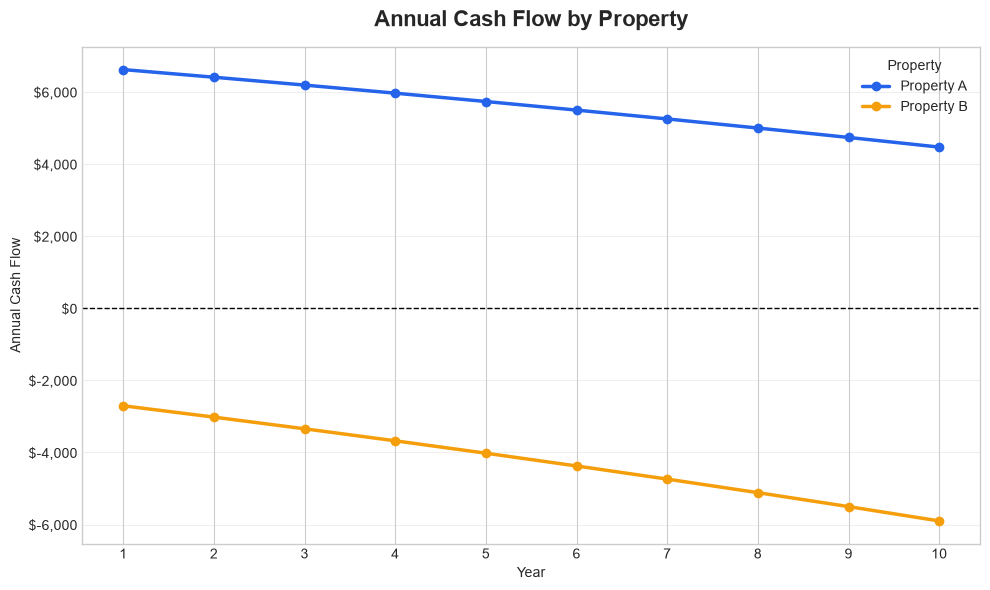

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for property_name, property_data in combined_projection.groupby("Property"):
    ax.plot(
        property_data["Year"],
        property_data["Annual Cash Flow"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=property_name,
        color=property_colors[property_name],
    )

ax.axhline(
    y=0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Annual Cash Flow by Property",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Cash Flow")
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend(title="Property")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('annual_cash_flow.png')
plt.show()

### 7.2 Projected Property Values

Both properties use the same annual appreciation assumption, but Property B generates a larger dollar appreciation gain because it begins with a higher value.

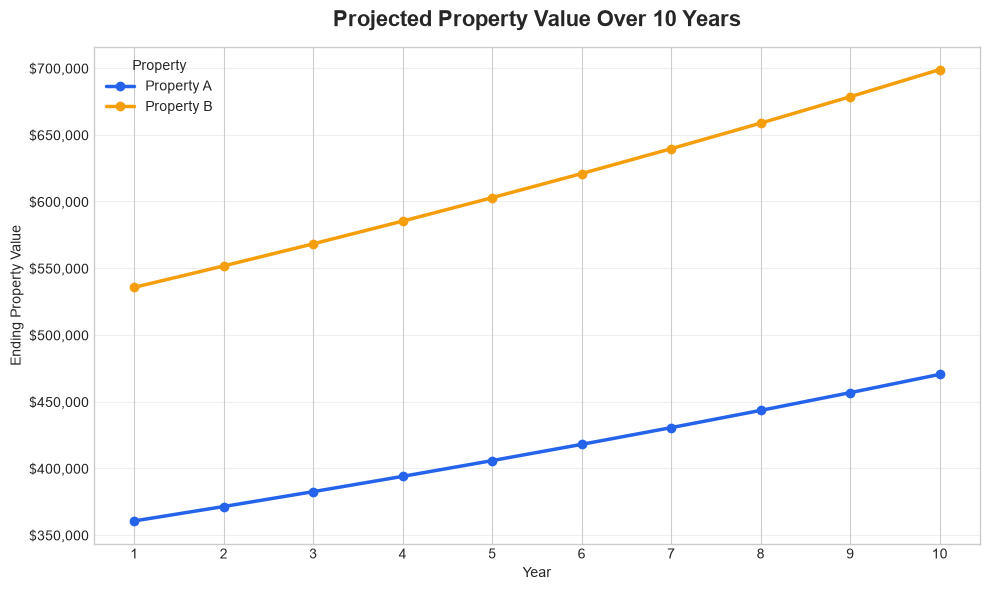

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

for property_name, property_data in combined_projection.groupby("Property"):
    ax.plot(
        property_data["Year"],
        property_data["Ending Property Value"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=property_name,
        color=property_colors[property_name],
    )

ax.set_title(
    "Projected Property Value Over 10 Years",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year")
ax.set_ylabel("Ending Property Value")
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend(title="Property")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('property_value_over_10_yrs')
plt.show()

### 7.3 Remaining Mortgage Balance

This chart shows how each mortgage balance declines over the 10-year holding period.

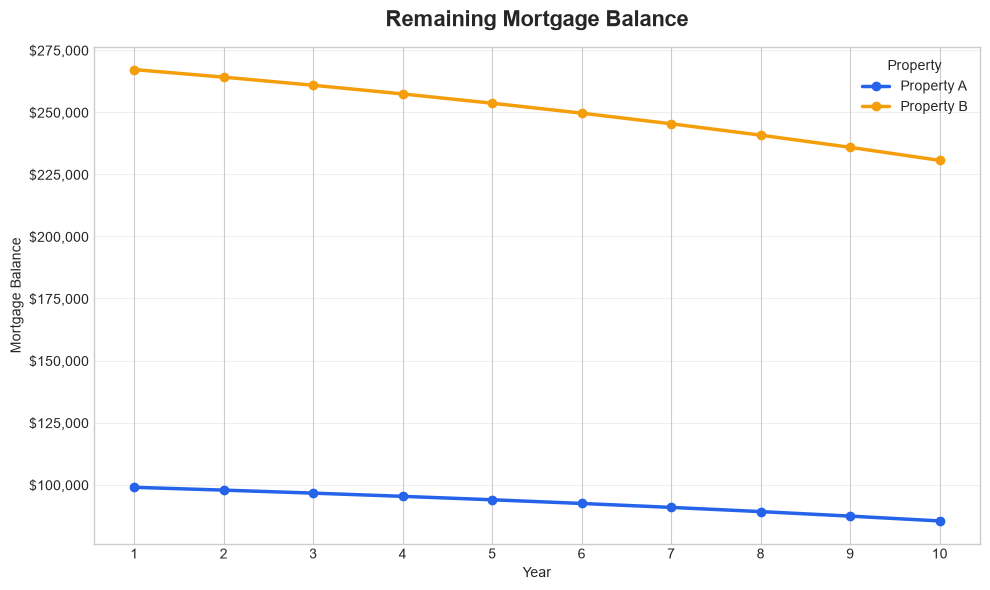

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for property_name, property_data in combined_projection.groupby("Property"):
    ax.plot(
        property_data["Year"],
        property_data["Ending Mortgage Balance"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=property_name,
        color=property_colors[property_name],
    )

ax.set_title(
    "Remaining Mortgage Balance",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year")
ax.set_ylabel("Mortgage Balance")
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend(title="Property")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('remaining_mortgage_balance.png')
plt.show()

### 7.4 Components of Total Profit

Total profit consists of cumulative rental cash flow plus net sale proceeds, minus the initial cash investment.

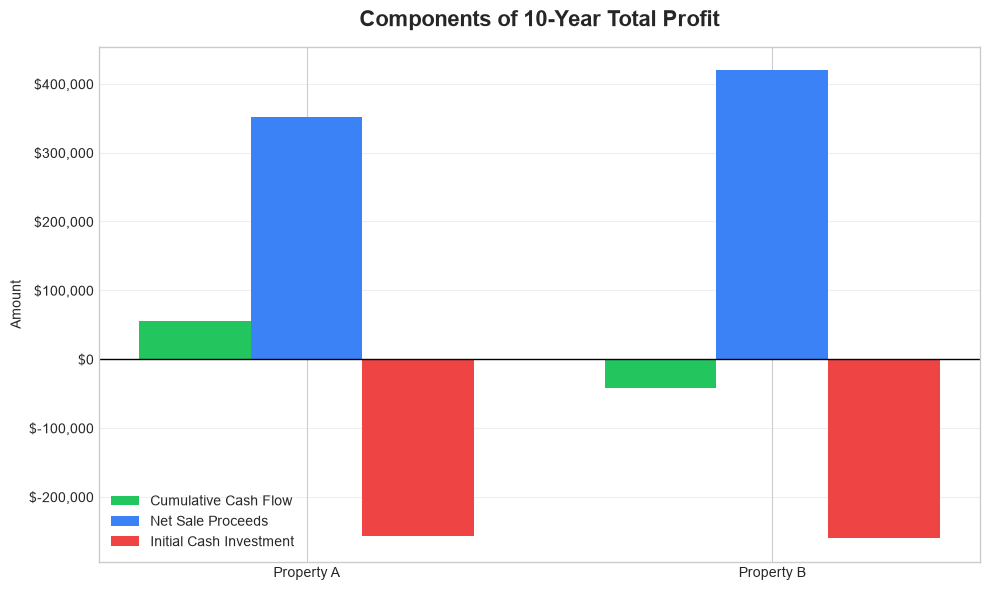

In [18]:
properties = ["Property A", "Property B"]

cumulative_cash_flow = [
    property_a_summary["Cumulative Cash Flow"],
    property_b_summary["Cumulative Cash Flow"],
]

net_sale_proceeds = [
    property_a_summary["Net Sale Proceeds"],
    property_b_summary["Net Sale Proceeds"],
]

initial_cash_investment = [
    -property_a_summary["Initial Cash Investment"],
    -property_b_summary["Initial Cash Investment"],
]

x_positions = np.arange(len(properties))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x_positions - bar_width,
    cumulative_cash_flow,
    width=bar_width,
    label="Cumulative Cash Flow",
    color="#22C55E",
)

ax.bar(
    x_positions,
    net_sale_proceeds,
    width=bar_width,
    label="Net Sale Proceeds",
    color="#3B82F6",
)

ax.bar(
    x_positions + bar_width,
    initial_cash_investment,
    width=bar_width,
    label="Initial Cash Investment",
    color="#EF4444",
)

ax.axhline(
    y=0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Components of 10-Year Total Profit",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Amount")
ax.set_xticks(x_positions)
ax.set_xticklabels(properties)
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('10_yr_total_profit.png')
plt.show()

## 8. Appreciation Scenarios
Calculate potential scenarios by annual appreciation rate growth

In [19]:
scenario_rates = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
scenario_records = []

for appreciation_rate in scenario_rates:
    scenario_a = copy.deepcopy(property_a)
    scenario_b = copy.deepcopy(property_b)

    scenario_a["annual_appreciation"] = appreciation_rate
    scenario_b["annual_appreciation"] = appreciation_rate

    _, summary_a = project_property(scenario_a)
    _, summary_b = project_property(scenario_b)

    scenario_records.append({
        "Appreciation Rate": appreciation_rate,
        "Property A Total Profit": summary_a["Total Profit"],
        "Property B Total Profit": summary_b["Total Profit"],
        "B Minus A": (
            summary_b["Total Profit"]
            - summary_a["Total Profit"]
        ),
        "Better Property": (
            "Property B"
            if summary_b["Total Profit"] > summary_a["Total Profit"]
            else "Property A"
        ),
    })

scenario_results = pd.DataFrame(scenario_records)
scenario_results

,Appreciation Rate,Property A Total Profit,Property B Total Profit,B Minus A,Better Property
0,0.02,"113,886.08","61,502.07","-52,384.00",Property A
1,0.03,"150,920.27","116,524.31","-34,395.97",Property A
2,0.04,"191,469.05","176,768.20","-14,700.85",Property A
3,0.05,"235,820.22","242,661.36","6,841.15",Property B
4,0.06,"284,281.86","314,661.52","30,379.66",Property B
5,0.07,"337,183.53","393,258.30","56,074.76",Property B
6,0.08,"394,877.53","478,975.08","84,097.56",Property B
7,0.09,"457,740.19","572,371.04","114,630.85",Property B
8,0.10,"526,173.33","674,043.13","147,869.80",Property B


### 8.1 Total Profit Across Appreciation Scenarios

This chart tests whether Property B's larger appreciation gain can offset its weaker cumulative cash flow.

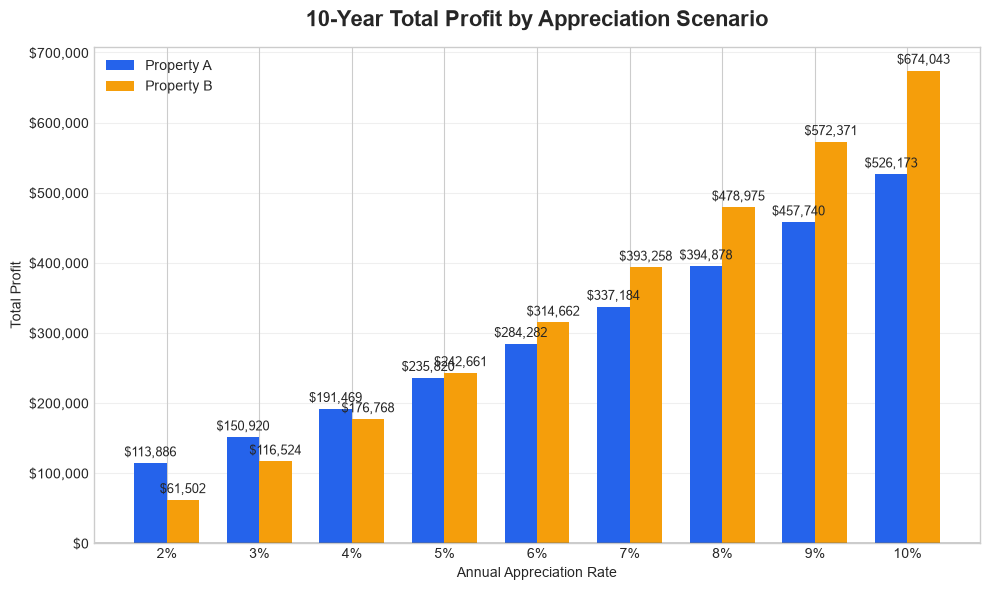

In [20]:
x_positions = np.arange(len(scenario_results))
bar_width = 0.35

property_a_profits = scenario_results[
    "Property A Total Profit"
].to_numpy()

property_b_profits = scenario_results[
    "Property B Total Profit"
].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))

property_a_bars = ax.bar(
    x_positions - bar_width / 2,
    property_a_profits,
    width=bar_width,
    label="Property A",
    color=property_colors["Property A"],
)

property_b_bars = ax.bar(
    x_positions + bar_width / 2,
    property_b_profits,
    width=bar_width,
    label="Property B",
    color=property_colors["Property B"],
)

ax.axhline(
    y=0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "10-Year Total Profit by Appreciation Scenario",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Annual Appreciation Rate")
ax.set_ylabel("Total Profit")
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [
        f"{rate:.0%}"
        for rate in scenario_results["Appreciation Rate"]
    ]
)
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax.bar_label(
    property_a_bars,
    labels=[f"${value:,.0f}" for value in property_a_profits],
    padding=3,
    fontsize=9,
)

ax.bar_label(
    property_b_bars,
    labels=[f"${value:,.0f}" for value in property_b_profits],
    padding=3,
    fontsize=9,
)

plt.tight_layout()
plt.savefig('total_profit_by_appreciation.png')
plt.show()

### 8.2 Calculate the break-even rate
Find the appreciation rate where Property B beats Property A

In [21]:
def profit_difference(appreciation_rate):
    scenario_a = copy.deepcopy(property_a)
    scenario_b = copy.deepcopy(property_b)

    scenario_a["annual_appreciation"] = appreciation_rate
    scenario_b["annual_appreciation"] = appreciation_rate

    _, summary_a = project_property(scenario_a)
    _, summary_b = project_property(scenario_b)

    return (
        summary_b["Total Profit"]
        - summary_a["Total Profit"]
    )

In [22]:
break_even_rate = brentq(
    profit_difference,
    0.00,
    0.20,
)

print(
    "Break-even annual appreciation rate:",
    f"{break_even_rate:.2%}",
)

Break-even annual appreciation rate: 4.69%


In [23]:
break_even_test_rates = np.linspace(0.00, 0.12, 121)

profit_differences = [
    profit_difference(rate)
    for rate in break_even_test_rates
]

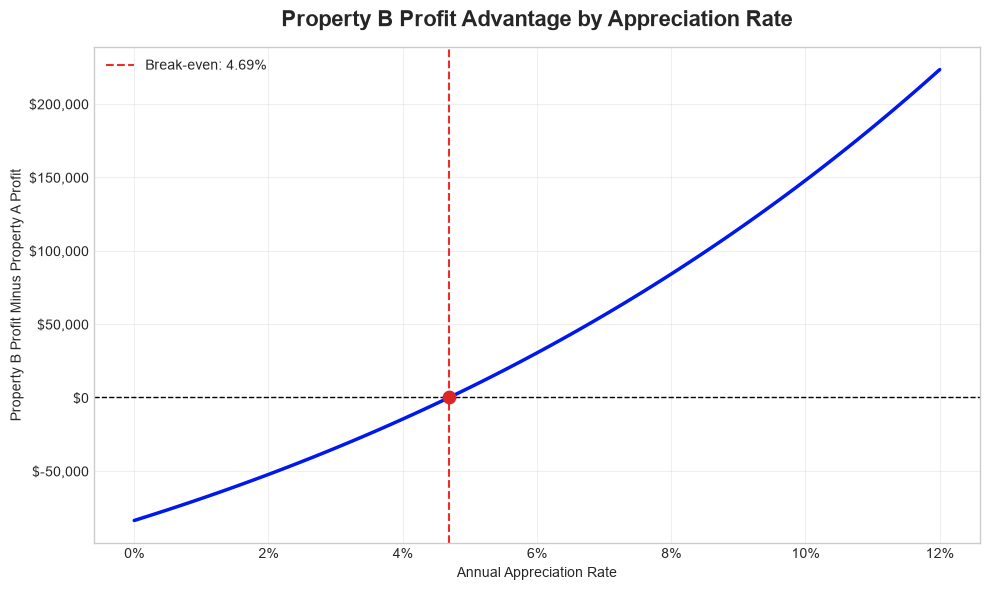

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    break_even_test_rates,
    profit_differences,
    color="#0018EE",
    linewidth=2.5,
)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    x=break_even_rate,
    color="#EC2E2B",
    linestyle="--",
    linewidth=1.5,
    label=f"Break-even: {break_even_rate:.2%}",
)

ax.scatter(
    break_even_rate,
    0,
    color="#DC2626",
    s=80,
    zorder=3,
)

ax.set_title(
    "Property B Profit Advantage by Appreciation Rate",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Annual Appreciation Rate")
ax.set_ylabel("Property B Profit Minus Property A Profit")
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0%}")
)
ax.yaxis.set_major_formatter(currency_formatter)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('property_b_profit_advantage.png')
plt.show()

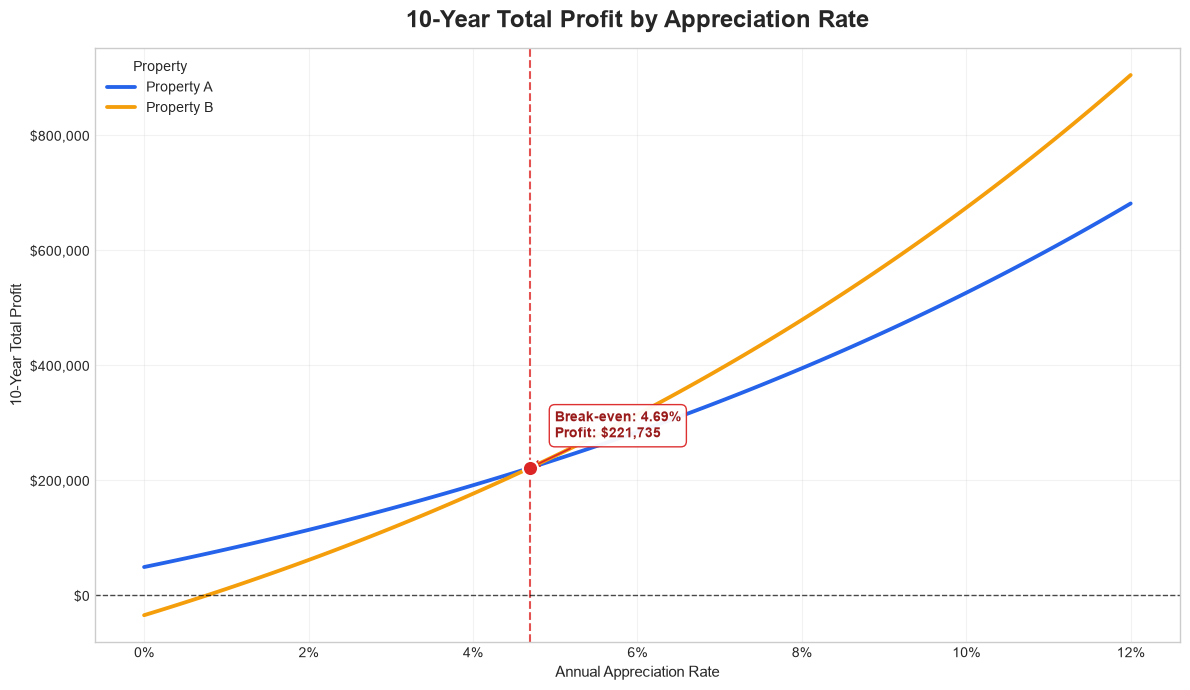

In [25]:
# Create a smooth range of appreciation rates from 0% to 12%.
appreciation_plot_rates = np.linspace(
    0.00,
    0.12,
    121,
)

property_a_plot_profits = []
property_b_plot_profits = []

# Calculate each property's total profit at every rate.
for appreciation_rate in appreciation_plot_rates:
    plot_scenario_a = copy.deepcopy(property_a)
    plot_scenario_b = copy.deepcopy(property_b)

    plot_scenario_a[
        "annual_appreciation"
    ] = appreciation_rate

    plot_scenario_b[
        "annual_appreciation"
    ] = appreciation_rate

    _, plot_summary_a = project_property(
        plot_scenario_a
    )

    _, plot_summary_b = project_property(
        plot_scenario_b
    )

    property_a_plot_profits.append(
        plot_summary_a["Total Profit"]
    )

    property_b_plot_profits.append(
        plot_summary_b["Total Profit"]
    )


# Calculate the exact profit at the break-even rate.
break_even_scenario_a = copy.deepcopy(property_a)
break_even_scenario_b = copy.deepcopy(property_b)

break_even_scenario_a[
    "annual_appreciation"
] = break_even_rate

break_even_scenario_b[
    "annual_appreciation"
] = break_even_rate

_, break_even_summary_a = project_property(
    break_even_scenario_a
)

_, break_even_summary_b = project_property(
    break_even_scenario_b
)

break_even_profit = (
    break_even_summary_a["Total Profit"]
    + break_even_summary_b["Total Profit"]
) / 2


# Create the chart.
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    appreciation_plot_rates,
    property_a_plot_profits,
    color=property_colors["Property A"],
    linewidth=2.75,
    label="Property A",
)

ax.plot(
    appreciation_plot_rates,
    property_b_plot_profits,
    color=property_colors["Property B"],
    linewidth=2.75,
    label="Property B",
)


# Mark the exact break-even point.
ax.scatter(
    break_even_rate,
    break_even_profit,
    s=120,
    color="#DC2626",
    edgecolor="white",
    linewidth=1.5,
    zorder=5,
)

ax.axvline(
    x=break_even_rate,
    color="#DC2626",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
)

ax.annotate(
    (
        f"Break-even: {break_even_rate:.2%}\n"
        f"Profit: ${break_even_profit:,.0f}"
    ),
    xy=(
        break_even_rate,
        break_even_profit,
    ),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    color="#991B1B",
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#DC2626",
        "alpha": 0.95,
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "#DC2626",
        "linewidth": 1.2,
    },
)


# Format the chart.
ax.set_title(
    "10-Year Total Profit by Appreciation Rate",
    fontsize=17,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Annual Appreciation Rate",
    fontsize=11,
)

ax.set_ylabel(
    "10-Year Total Profit",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0%}"
    )
)

ax.yaxis.set_major_formatter(currency_formatter)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.grid(
    axis="both",
    alpha=0.25,
)

ax.legend(
    title="Property",
    loc="upper left",
)

plt.tight_layout()
plt.show()

## 9. Operating-Assumption Sensitivity Analysis

The base model depends on assumptions that may change over the 10-year holding period. This section tests how total profit and the preferred property change under alternative assumptions for:

- Annual rent growth
- Vacancy
- Property management
- Insurance growth
- Property appreciation

Each one-way sensitivity test changes one assumption at a time while holding all other assumptions at their base values.

In [26]:
sensitivity_scenarios = {
    "annual_rent_growth": [0.00, 0.05, 0.10, 0.15, 0.20],
    "vacancy_rate": [0.05, 0.08, 0.10, 0.12, 0.15],
    "management_fee_rate": [0.00, 0.05, 0.08, 0.10, 0.15],
    "annual_insurance_growth": [0.00, 0.02, 0.05, 0.08, 0.10],
}

In [27]:
def run_one_way_sensitivity(
    parameter_name,
    parameter_values,
    base_property_a,
    base_property_b,
):
    sensitivity_records = []

    for parameter_value in parameter_values:
        scenario_a = copy.deepcopy(base_property_a)
        scenario_b = copy.deepcopy(base_property_b)

        # Apply the same operating assumption to both properties.
        scenario_a[parameter_name] = parameter_value
        scenario_b[parameter_name] = parameter_value

        _, summary_a = project_property(scenario_a)
        _, summary_b = project_property(scenario_b)

        profit_difference_value = (
            summary_b["Total Profit"]
            - summary_a["Total Profit"]
        )

        sensitivity_records.append({
            "Parameter": parameter_name,
            "Parameter Value": parameter_value,
            "Property A Total Profit": summary_a["Total Profit"],
            "Property B Total Profit": summary_b["Total Profit"],
            "B Minus A": profit_difference_value,
            "Better Property": (
                "Property B"
                if profit_difference_value > 0
                else "Property A"
            ),
        })

    return pd.DataFrame(sensitivity_records)

In [28]:
sensitivity_results = []

for parameter_name, parameter_values in sensitivity_scenarios.items():
    parameter_results = run_one_way_sensitivity(
        parameter_name=parameter_name,
        parameter_values=parameter_values,
        base_property_a=property_a,
        base_property_b=property_b,
    )

    sensitivity_results.append(parameter_results)

sensitivity_results = pd.concat(
    sensitivity_results,
    ignore_index=True,
)

### 9.1 Display results

In [29]:
sensitivity_display = sensitivity_results.copy()

parameter_labels = {
    "annual_rent_growth": "Annual Rent Growth",
    "vacancy_rate": "Vacancy Rate",
    "management_fee_rate": "Management Fee",
    "annual_insurance_growth": "Annual Insurance Growth",
}

sensitivity_display["Parameter"] = (
    sensitivity_display["Parameter"]
    .map(parameter_labels)
)

sensitivity_display["Parameter Value"] = (
    sensitivity_display["Parameter Value"]
    .map(lambda value: f"{value:.0%}")
)

currency_columns = [
    "Property A Total Profit",
    "Property B Total Profit",
    "B Minus A",
]

for column in currency_columns:
    sensitivity_display[column] = (
        sensitivity_display[column]
        .map(lambda value: f"${value:,.0f}")
    )

sensitivity_display

,Parameter,Parameter Value,Property A Total Profit,Property B Total Profit,B Minus A,Better Property
0,Annual Rent Growth,0%,"$150,920","$116,524","$-34,396",Property A
1,Annual Rent Growth,5%,"$224,390","$219,382","$-5,008",Property A
2,Annual Rent Growth,10%,"$320,137","$353,428","$33,291",Property B
3,Annual Rent Growth,15%,"$444,576","$527,643","$83,066",Property B
4,Annual Rent Growth,20%,"$605,743","$753,276","$147,533",Property B
5,Vacancy Rate,5%,"$150,920","$116,524","$-34,396",Property A
6,Vacancy Rate,8%,"$141,920","$103,924","$-37,996",Property A
7,Vacancy Rate,10%,"$135,920","$95,524","$-40,396",Property A
8,Vacancy Rate,12%,"$129,920","$87,124","$-42,796",Property A
9,Vacancy Rate,15%,"$120,920","$74,524","$-46,396",Property A


### 9.2 Validate results

In [30]:
base_rent_growth_result = sensitivity_results[
    (sensitivity_results["Parameter"] == "annual_rent_growth")
    & (sensitivity_results["Parameter Value"] == 0.00)
].iloc[0]

assert np.isclose(
    base_rent_growth_result["Property A Total Profit"],
    property_a_summary["Total Profit"],
    atol=1.00,
)

assert np.isclose(
    base_rent_growth_result["Property B Total Profit"],
    property_b_summary["Total Profit"],
    atol=1.00,
)

print("Sensitivity validation passed.")

Sensitivity validation passed.


### 9.3 Total Profit Under Alternative Operating Assumptions

Each panel changes one assumption while holding all other assumptions at their base values.

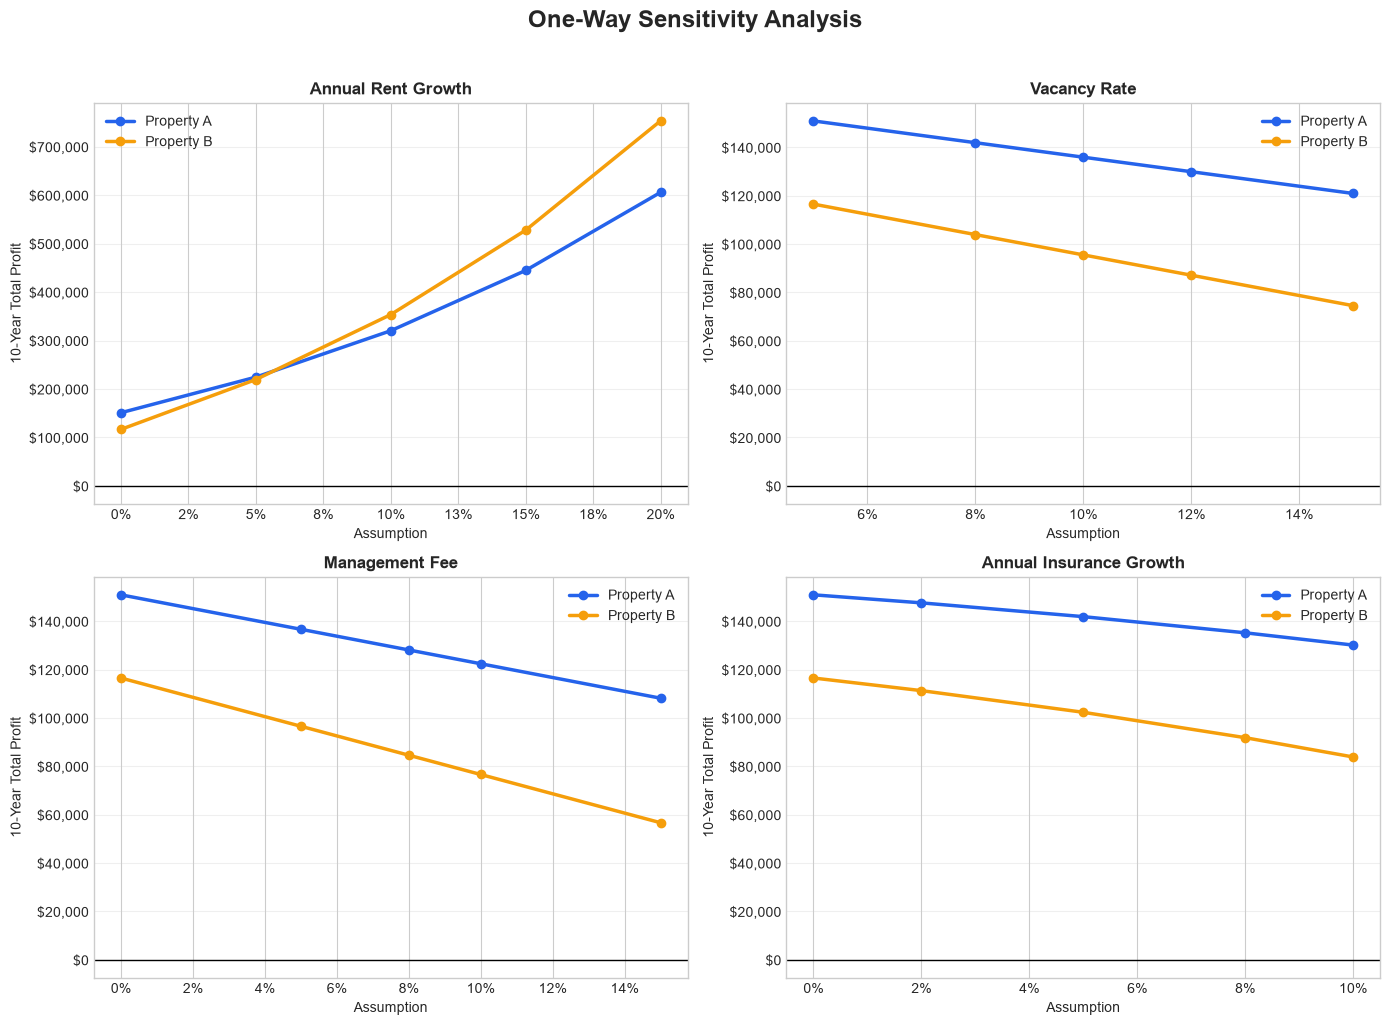

In [31]:
plot_parameters = [
    ("annual_rent_growth", "Annual Rent Growth"),
    ("vacancy_rate", "Vacancy Rate"),
    ("management_fee_rate", "Management Fee"),
    ("annual_insurance_growth", "Annual Insurance Growth"),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)

axes = axes.flatten()

for ax, (parameter_name, parameter_title) in zip(
    axes,
    plot_parameters,
):
    parameter_data = sensitivity_results[
        sensitivity_results["Parameter"] == parameter_name
    ].sort_values("Parameter Value")

    ax.plot(
        parameter_data["Parameter Value"],
        parameter_data["Property A Total Profit"],
        marker="o",
        linewidth=2.5,
        label="Property A",
        color=property_colors["Property A"],
    )

    ax.plot(
        parameter_data["Parameter Value"],
        parameter_data["Property B Total Profit"],
        marker="o",
        linewidth=2.5,
        label="Property B",
        color=property_colors["Property B"],
    )

    ax.set_title(parameter_title, fontweight="bold")
    ax.set_xlabel("Assumption")
    ax.set_ylabel("10-Year Total Profit")

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: f"{value:.0%}"
        )
    )

    ax.yaxis.set_major_formatter(currency_formatter)
    ax.axhline(0, color="black", linewidth=1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

fig.suptitle(
    "One-Way Sensitivity Analysis",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.savefig('one_way_sensitivity_analysis.png')
plt.show()

### 9.4 Show Profit Advantage

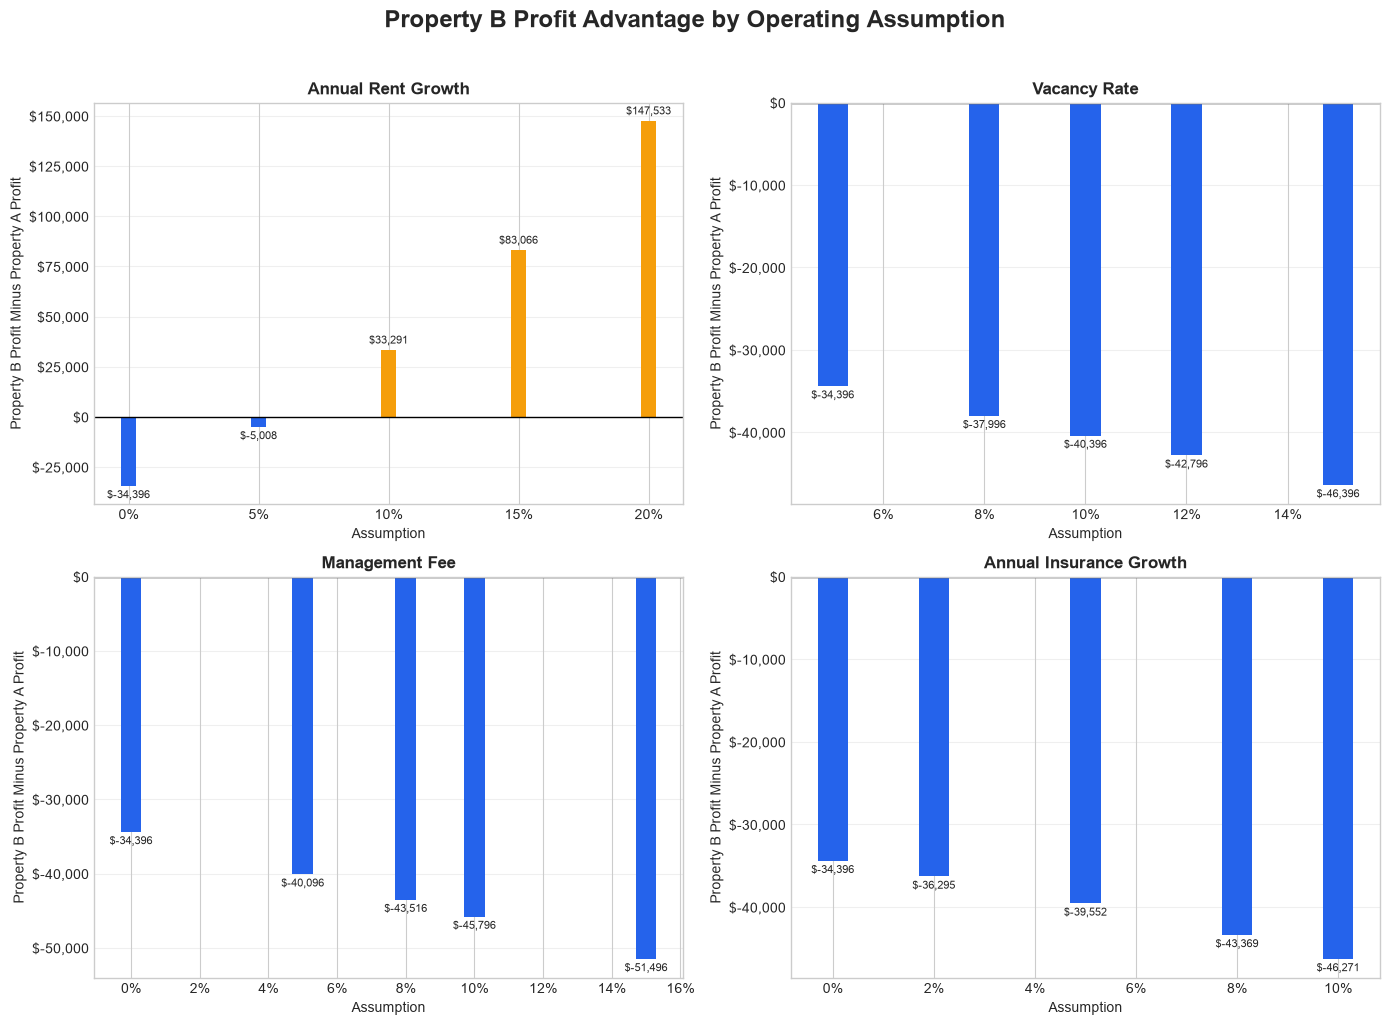

In [32]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)

axes = axes.flatten()

for ax, (parameter_name, parameter_title) in zip(
    axes,
    plot_parameters,
):
    parameter_data = sensitivity_results[
        sensitivity_results["Parameter"] == parameter_name
    ].sort_values("Parameter Value")

    bar_colors = [
        property_colors["Property B"]
        if value > 0
        else property_colors["Property A"]
        for value in parameter_data["B Minus A"]
    ]

    bars = ax.bar(
        parameter_data["Parameter Value"],
        parameter_data["B Minus A"],
        width=0.006,
        color=bar_colors,
    )

    ax.axhline(
        y=0,
        color="black",
        linewidth=1,
    )

    ax.set_title(parameter_title, fontweight="bold")
    ax.set_xlabel("Assumption")
    ax.set_ylabel("Property B Profit Minus Property A Profit")

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: f"{value:.0%}"
        )
    )

    ax.yaxis.set_major_formatter(currency_formatter)
    ax.grid(axis="y", alpha=0.3)

    ax.bar_label(
        bars,
        labels=[
            f"${value:,.0f}"
            for value in parameter_data["B Minus A"]
        ],
        padding=3,
        fontsize=8,
    )

fig.suptitle(
    "Property B Profit Advantage by Operating Assumption",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.savefig('profit_advantage_by_assumption')
plt.show()

### 9.5 Calculate break-even appreciation for each scenario

In [33]:
def calculate_break_even_appreciation(
    scenario_property_a,
    scenario_property_b,
    lower_bound=0.00,
    upper_bound=0.20,
):
    def scenario_profit_difference(appreciation_rate):
        appreciation_scenario_a = copy.deepcopy(
            scenario_property_a
        )
        appreciation_scenario_b = copy.deepcopy(
            scenario_property_b
        )

        appreciation_scenario_a[
            "annual_appreciation"
        ] = appreciation_rate

        appreciation_scenario_b[
            "annual_appreciation"
        ] = appreciation_rate

        _, summary_a = project_property(
            appreciation_scenario_a
        )
        _, summary_b = project_property(
            appreciation_scenario_b
        )

        return (
            summary_b["Total Profit"]
            - summary_a["Total Profit"]
        )

    try:
        return brentq(
            scenario_profit_difference,
            lower_bound,
            upper_bound,
        )
    except ValueError:
        return np.nan

In [34]:
break_even_records = []

for parameter_name, parameter_values in sensitivity_scenarios.items():
    for parameter_value in parameter_values:
        scenario_a = copy.deepcopy(property_a)
        scenario_b = copy.deepcopy(property_b)

        scenario_a[parameter_name] = parameter_value
        scenario_b[parameter_name] = parameter_value

        scenario_break_even = calculate_break_even_appreciation(
            scenario_a,
            scenario_b,
        )

        break_even_records.append({
            "Parameter": parameter_name,
            "Parameter Value": parameter_value,
            "Break-Even Appreciation": scenario_break_even,
        })

break_even_sensitivity = pd.DataFrame(
    break_even_records
)

In [35]:
break_even_display = break_even_sensitivity.copy()

break_even_display["Parameter"] = (
    break_even_display["Parameter"]
    .map(parameter_labels)
)

break_even_display["Parameter Value"] = (
    break_even_display["Parameter Value"]
    .map(lambda value: f"{value:.0%}")
)

break_even_display["Break-Even Appreciation"] = (
    break_even_display["Break-Even Appreciation"]
    .map(
        lambda value: (
            f"{value:.2%}"
            if pd.notna(value)
            else "No crossover"
        )
    )
)

break_even_display

,Parameter,Parameter Value,Break-Even Appreciation
0,Annual Rent Growth,0%,4.69%
1,Annual Rent Growth,5%,3.26%
2,Annual Rent Growth,10%,1.07%
3,Annual Rent Growth,15%,No crossover
4,Annual Rent Growth,20%,No crossover
5,Vacancy Rate,5%,4.69%
6,Vacancy Rate,8%,4.86%
7,Vacancy Rate,10%,4.96%
8,Vacancy Rate,12%,5.07%
9,Vacancy Rate,15%,5.23%


### 9.6 Rent-Growth vs. Vacancy

Correlated heatmap

In [36]:
rent_growth_rates = [0.00, 0.01, 0.02, 0.03]
vacancy_rates = [0.05, 0.08, 0.10, 0.12]

two_way_records = []

for rent_growth_rate in rent_growth_rates:
    for vacancy_rate in vacancy_rates:
        scenario_a = copy.deepcopy(property_a)
        scenario_b = copy.deepcopy(property_b)

        scenario_a["annual_rent_growth"] = rent_growth_rate
        scenario_b["annual_rent_growth"] = rent_growth_rate

        scenario_a["vacancy_rate"] = vacancy_rate
        scenario_b["vacancy_rate"] = vacancy_rate

        _, summary_a = project_property(scenario_a)
        _, summary_b = project_property(scenario_b)

        two_way_records.append({
            "Rent Growth": rent_growth_rate,
            "Vacancy Rate": vacancy_rate,
            "B Minus A": (
                summary_b["Total Profit"]
                - summary_a["Total Profit"]
            ),
        })

two_way_sensitivity = pd.DataFrame(two_way_records)

In [37]:
sensitivity_matrix = two_way_sensitivity.pivot(
    index="Vacancy Rate",
    columns="Rent Growth",
    values="B Minus A",
)

sensitivity_matrix

Rent Growth,0.00,0.01,0.02,0.03
Vacancy Rate,,,,
0.05,"-34,395.97","-29,126.74","-23,569.15","-17,707.74"
0.08,"-37,995.97","-32,893.14","-27,511.05","-21,834.74"
0.10,"-40,395.97","-35,404.07","-30,138.98","-24,586.07"
0.12,"-42,795.97","-37,915.00","-32,766.91","-27,337.40"


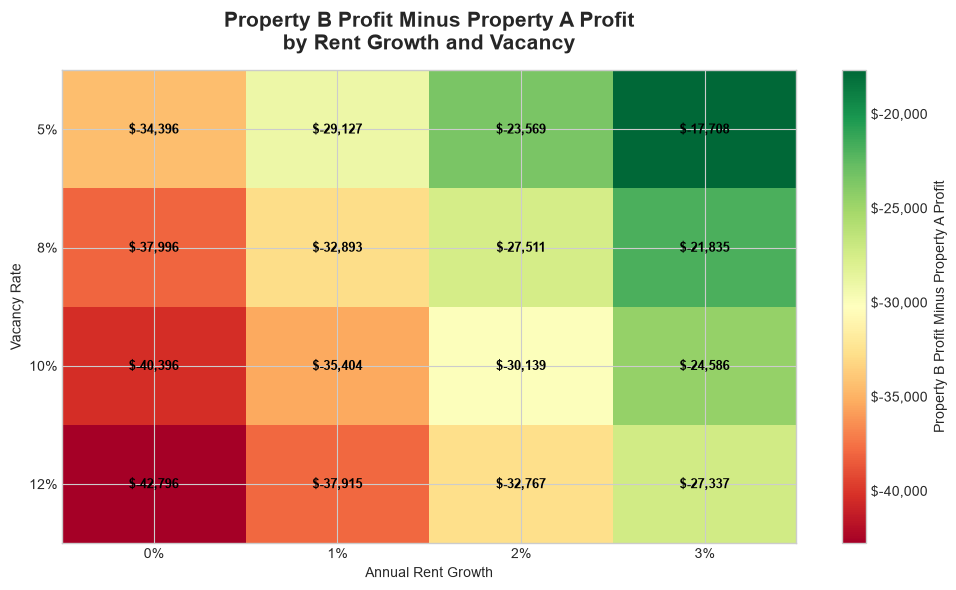

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

heatmap = ax.imshow(
    sensitivity_matrix.values,
    cmap="RdYlGn",
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(sensitivity_matrix.columns))
)
ax.set_xticklabels(
    [
        f"{value:.0%}"
        for value in sensitivity_matrix.columns
    ]
)

ax.set_yticks(
    np.arange(len(sensitivity_matrix.index))
)
ax.set_yticklabels(
    [
        f"{value:.0%}"
        for value in sensitivity_matrix.index
    ]
)

ax.set_xlabel("Annual Rent Growth")
ax.set_ylabel("Vacancy Rate")

ax.set_title(
    "Property B Profit Minus Property A Profit\n"
    "by Rent Growth and Vacancy",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

for row_index in range(
    len(sensitivity_matrix.index)
):
    for column_index in range(
        len(sensitivity_matrix.columns)
    ):
        value = sensitivity_matrix.iloc[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"${value:,.0f}",
            ha="center",
            va="center",
            color=(
                "white"
                if abs(value) > 50_000
                else "black"
            ),
            fontsize=9,
            fontweight="bold",
        )

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Property B Profit Minus Property A Profit")
colorbar.ax.yaxis.set_major_formatter(currency_formatter)

plt.tight_layout()
plt.savefig('rent_growth_vs_vacancy.png')
plt.show()

### 9.7 Rank assumption efforts

In [39]:
sensitivity_impact = (
    sensitivity_results
    .groupby("Parameter")["B Minus A"]
    .agg(["min", "max"])
)

sensitivity_impact["Impact Range"] = (
    sensitivity_impact["max"]
    - sensitivity_impact["min"]
)

sensitivity_impact = (
    sensitivity_impact
    .sort_values(
        "Impact Range",
        ascending=False,
    )
)

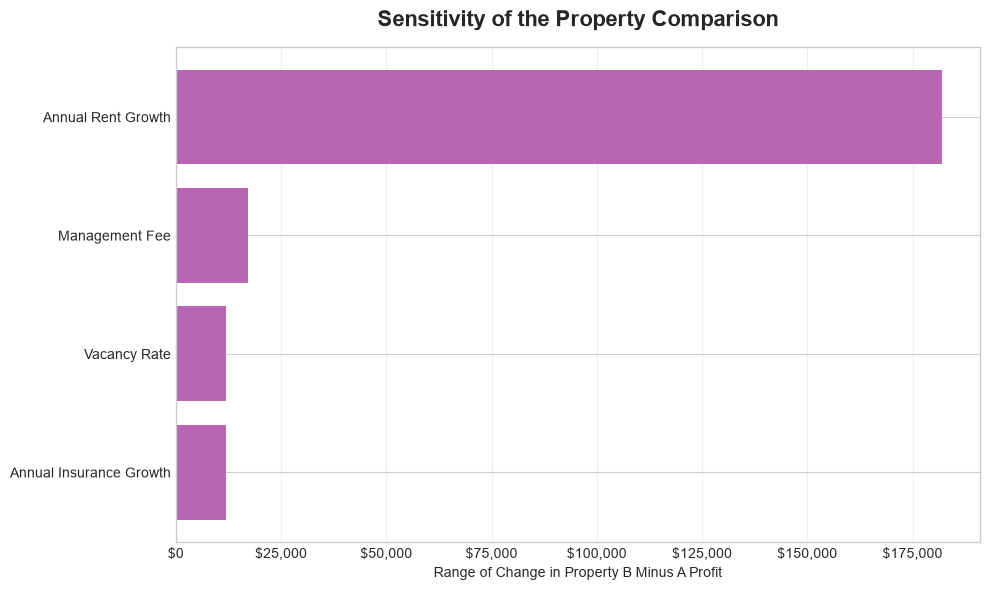

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

impact_labels = [
    parameter_labels.get(parameter, parameter)
    for parameter in sensitivity_impact.index
]

ax.barh(
    impact_labels,
    sensitivity_impact["Impact Range"],
    color="#B866B2",
)

ax.set_title(
    "Sensitivity of the Property Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Range of Change in Property B Minus A Profit")
ax.xaxis.set_major_formatter(currency_formatter)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('property_sensitivity_comparison.png')
plt.show()

## Sensitivity Analysis Takeaways

- Property A remains the better investment across [insert tested scenarios where Property A wins].
- The comparison is most sensitive to [insert highest-impact assumption].
- Increasing rent growth improves both properties, but [state which property benefits more and why].
- Higher vacancy reduces the return of both properties and changes the profit difference by approximately [insert amount].
- Adding professional management fees reduces total profit because the fee is based on collected rent.
- Insurance growth lowers both properties' returns, with a larger dollar effect on Property B because its starting insurance cost is higher.
- The base-case break-even appreciation rate is 5.19%, while the tested operating scenarios produce break-even rates ranging from [minimum] to [maximum].
- The investment recommendation is [stable/sensitive] across the tested assumptions.

## Final Validation

In [41]:
# Confirm that the original base assumptions were not changed.
assert property_a["annual_rent_growth"] == 0.00
assert property_b["annual_rent_growth"] == 0.00

assert property_a["vacancy_rate"] == 0.05
assert property_b["vacancy_rate"] == 0.05

assert property_a["annual_appreciation"] == 0.03
assert property_b["annual_appreciation"] == 0.03


# Calculate the expected number of sensitivity results
# from the scenario lists currently being used.
expected_one_way_rows = sum(
    len(values)
    for values in sensitivity_scenarios.values()
)

expected_two_way_rows = (
    len(rent_growth_rates)
    * len(vacancy_rates)
)


# Confirm that every requested scenario was calculated.
assert len(sensitivity_results) == expected_one_way_rows, (
    f"Expected {expected_one_way_rows} one-way sensitivity rows, "
    f"but found {len(sensitivity_results)}."
)

assert len(two_way_sensitivity) == expected_two_way_rows, (
    f"Expected {expected_two_way_rows} two-way sensitivity rows, "
    f"but found {len(two_way_sensitivity)}."
)


print(
    "Sensitivity analysis completed without changing "
    "the original base assumptions."
)

print(
    f"Validated {len(sensitivity_results)} "
    "one-way sensitivity scenarios."
)

print(
    f"Validated {len(two_way_sensitivity)} "
    "two-way sensitivity scenarios."
)

Sensitivity analysis completed without changing the original base assumptions.
Validated 20 one-way sensitivity scenarios.
Validated 16 two-way sensitivity scenarios.


## Key Findings

- Under the 3% base-case appreciation assumption, Property A generates approximately $150,920 in total profit, compared with approximately $97,396 for Property B. Property A therefore outperforms Property B by approximately $53,525 over the 10-year holding period.
- Property A produces approximately $55,880 in positive cumulative cash flow, while Property B produces approximately $72,805 in negative cumulative cash flow. Property B’s larger mortgage and operating expenses require additional owner contributions during the holding period.
- Property B generates greater dollar appreciation and higher net sale proceeds because its initial property value is $200,000 higher. However, under the base assumptions, this additional appreciation is insufficient to offset its weaker rental cash flow.
- Property A remains the better investment under annual appreciation assumptions of 2%, 3%, 4%, and 5%. The estimated appreciation break-even rate is approximately 5.19% per year. Above this rate, Property B produces the greater total profit; below it, Property A remains the stronger investment.
- The one-way sensitivity analysis shows that annual rent growth has the clearest potential to change the investment ranking. Because Property B begins with higher monthly rent, it receives a larger dollar benefit when rents grow rapidly.
- Higher vacancy, management fees, and insurance growth reduce the profitability of both properties. These assumptions generally place greater pressure on Property B because it begins with higher rental income, insurance costs, and financing expenses.
- The two-way rent-growth and vacancy analysis demonstrates that the recommendation depends on the interaction between revenue growth and rental occupancy. Property B becomes more competitive when rent grows strongly and vacancy remains controlled, while Property A is more resilient under conservative rental conditions.
- Overall, Property A offers the stronger balance of cash flow and total return under the base and conservative scenarios. Property B represents a more appreciation-dependent investment with greater upside if Celina experiences sustained price and rent growth.

## Limitations

- The model evaluates two hypothetical Celina properties rather than specific homes. Actual results will depend on each property’s address, condition, size, subdivision, school district, HOA, and tenant demand.
- Monthly rents of $2,500 and $3,500 are assumptions and should be validated using comparable long-term rental listings, executed leases, or a local property manager’s estimate.
- The base model assumes 0% annual rent growth. Although the sensitivity analysis tests higher growth rates, actual rent growth may vary considerably from year to year.
- The 2.016% property-tax rate is a preliminary Celina-area assumption. The actual rate may be higher if a property is located within a MUD, PID, or other special taxing district.
- Property taxes are modeled as a constant percentage of projected property value. Actual assessed values, exemptions, appraisal practices, and tax rates may not change at the same rate as market value.
- Insurance and maintenance costs are estimated rather than based on property-specific quotes. The model does not explicitly include major capital expenditures such as roof replacement, HVAC replacement, foundation repairs, or storm damage.
- HOA fees are currently assumed to be zero. Any HOA dues, special assessments, leasing restrictions, or property-management requirements would reduce returns.
- The model assumes the properties remain rentable throughout the 10-year period, subject only to the selected vacancy rate. It does not separately model tenant turnover, leasing commissions, eviction costs, unpaid rent, or extended renovation periods.
- The appreciation scenarios are conditional assumptions rather than forecasts. The 5.19% break-even rate identifies what Property B would need to outperform Property A under the modeled conditions, but it does not establish that Celina will achieve that rate.
- Both properties are assigned the same appreciation rate. In reality, differences in location, construction quality, lot size, age, amenities, and neighborhood development may cause the properties to appreciate at different rates.
- Selling costs are estimated at 7% of the projected sale price. Actual commissions, concessions, repairs, closing expenses, and marketing costs may differ.
- The analysis excludes income taxes, depreciation, depreciation recapture, capital-gains taxes, financing fees, and the tax consequences of selling an investment property.
- The simplified annualized return does not account for the exact timing of annual cash flows. An XIRR calculation would provide a more precise annualized return when yearly cash contributions and distributions are included.
- Sensitivity analysis shows how results change under selected assumptions, but it does not estimate the probability of each scenario. The results should therefore be interpreted as conditional outcomes rather than predictions.